In [68]:
import pandas as pd

In [69]:
weather = pd.read_pickle('../data/PRISM/df.pkl')



weather = (
    weather
    .groupby("date", as_index=False)
    .first()
)


weather['date'] = pd.to_datetime(weather['date'])
weather['doy'] = weather['date'].dt.dayofyear
weather['year'] = weather['date'].dt.year

weather = weather.drop(weather[weather['year'] == 2025].index)
weather

,date,n,ppt,tmax,tmean,tmin,vpdmax,vpdmin,doy,year
0,2016-01-01,1,0.0000,-0.415000,-3.15300,-5.8920,2.1920,0.4860,1,2016
1,2016-01-02,1,0.0000,-4.138000,-5.38000,-6.6220,1.1680,0.5970,2,2016
2,2016-01-03,1,0.0000,-4.943000,-6.42400,-7.9050,1.1660,0.5900,3,2016
3,2016-01-04,1,1.0160,-4.861000,-6.44800,-8.0370,0.8410,0.2900,4,2016
4,2016-01-05,1,0.0000,-2.711000,-4.31500,-5.9210,1.1300,0.2980,5,2016
...,...,...,...,...,...,...,...,...,...,...
3283,2024-12-27,1,5.5226,12.897300,8.57640,4.2555,5.3272,0.0464,362,2024
3284,2024-12-28,1,2.7350,9.500899,6.92395,4.3470,1.8989,0.0603,363,2024
3285,2024-12-29,1,6.4769,13.031700,9.00255,4.9734,4.6196,0.0594,364,2024
3286,2024-12-30,1,0.9107,9.572500,6.35390,3.1353,2.6949,0.1705,365,2024


In [70]:
import matplotlib.pyplot as plt

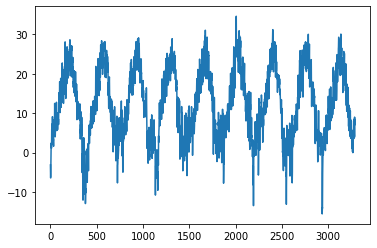

In [71]:
plt.plot(weather['tmean'])

In [74]:
from statsmodels.tsa.seasonal import STL
series = weather['tmean']

# STL
stl = STL(series, period=365, robust=True)
res = stl.fit()

weather['trend'] = res.trend
weather['seasonal'] = res.seasonal
weather['resid'] = res.resid

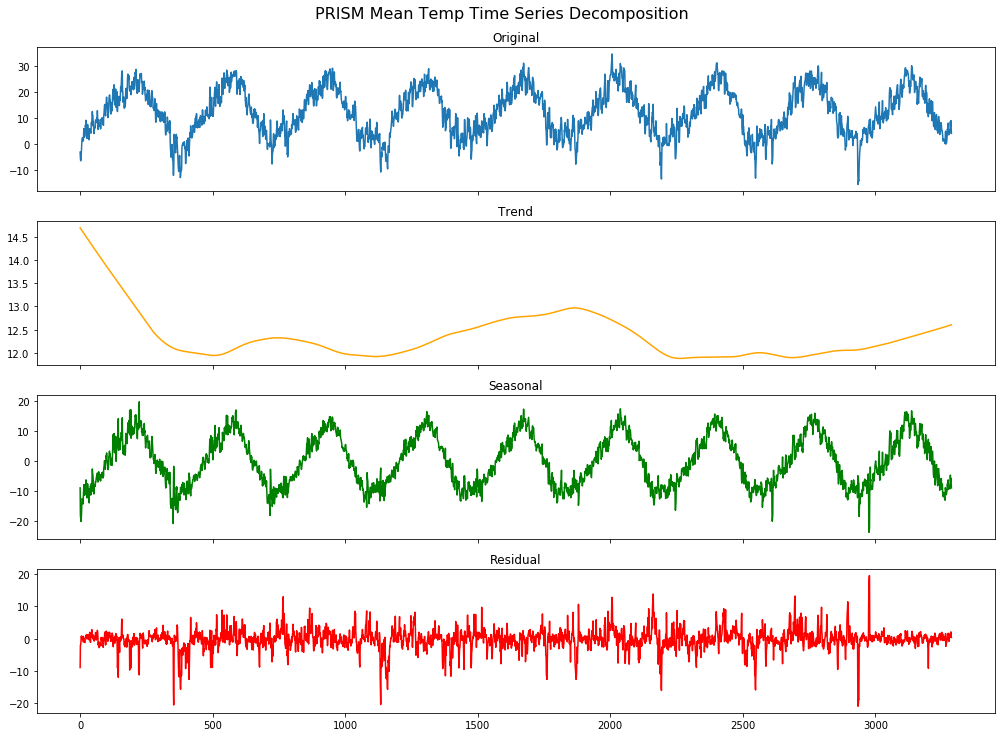

In [81]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4,1, figsize=(14,10), sharex=True)

axs[0].plot(series, label='NDVI')
axs[0].set_title('Original')

axs[1].plot(res.trend, color='orange')
axs[1].set_title('Trend')

axs[2].plot(res.seasonal, color='green')
axs[2].set_title('Seasonal')

axs[3].plot(res.resid, color='red')
axs[3].set_title('Residual')

plt.tight_layout()
plt.suptitle('PRISM Mean Temp Time Series Decomposition', y = 1.02, fontsize = 16)
plt.savefig('../img/temp_timeseries.png')
plt.show()


In [60]:
def decomp_ts(ts, period, model = 'additive'):
    res = sts.seasonal_decompose(ts, model = model, period = period)
    return(pd.DataFrame({'ts': ts, 'trend': res.trend, 'seasonal': res.seasonal, 'resid': res.resid}, 
                        index = ts.index))

def plot_acf_pacf(x, lags = 40):
    x = x[x.notna()] # remove NAs
    fig, axes = plt.subplots(1, 2, figsize = (15, 5))
    fig = splt.plot_acf(x, lags = lags, ax = axes[0])
    fig = splt.plot_pacf(x, lags = lags, ax = axes[1]);
    return None

def plot_ts_resid(x):
    x = x[x.notna()] # remove NAs
    fig, axes = plt.subplots(1, 2, figsize = (15, 5))
    fig = sns.lineplot(x, ax = axes[0])
    fig = sns.distplot(x, ax = axes[1]);
    return None

In [64]:
import statsmodels.tsa.seasonal as sts

df = decomp_ts(ts = weather['tmean'], period = 365, model = 'additive')

df = df.dropna(axis = 0)

<Figure size 1440x1080 with 0 Axes>

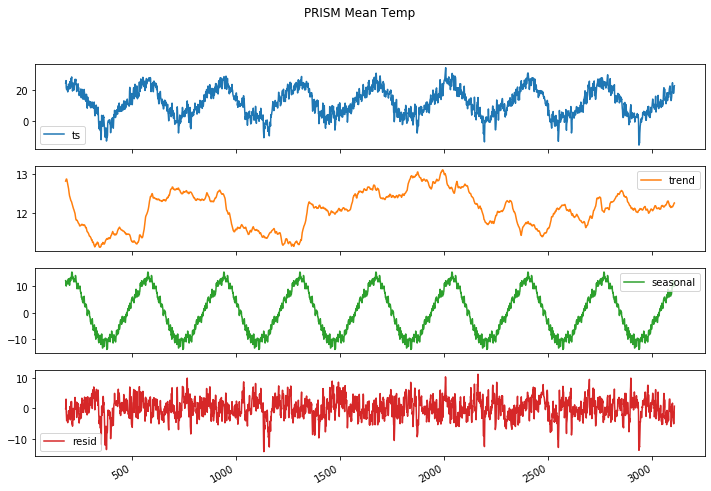

In [65]:
plt.figure(figsize = (20,15))

df.plot(subplots = True, figsize = (12,8), title = 'PRISM Mean Temp')
plt.savefig('../img/temp_timeseries.png')